# Fleet MOT Failure Risk Model

## Notebook 04: MOT Failure Risk Model

This notebook builds a simple machine learning model to predict whether a vehicle is likely to fail its MOT.

The purpose of this notebook is to:

- Load the cleaned MOT sample dataset
- Prepare the target variable
- Select useful model features
- Split the data into training and test sets
- Build a baseline model
- Train a logistic regression model
- Evaluate model performance
- Review accuracy, precision, recall and F1 score
- Save the trained model for future use

This model is not intended to replace expert vehicle inspection. It is designed to show how MOT data can support fleet maintenance risk analysis and prioritisation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Define project paths

processed_data_path = Path("../data/processed")
models_path = Path("../models")
reports_path = Path("../reports")

cleaned_file = processed_data_path / "mot_2024_cleaned_sample.csv"

models_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print("Cleaned file exists:", cleaned_file.exists())
print("Models folder exists:", models_path.exists())
print("Reports folder exists:", reports_path.exists())

Cleaned file exists: True
Models folder exists: True
Reports folder exists: True


In [3]:
# Load cleaned MOT sample dataset

mot = pd.read_csv(cleaned_file, low_memory=False)

print("Dataset loaded successfully.")
print("Rows:", mot.shape[0])
print("Columns:", mot.shape[1])

Dataset loaded successfully.
Rows: 600000
Columns: 18


## Prepare Target Variable

The target variable for this model is whether the vehicle failed its MOT.

The model will predict:

- 1 = Fail
- 0 = Pass

In [4]:
# Create a clean numeric target variable

mot_model = mot.copy()

# Convert is_fail safely into 1/0
mot_model["target_fail"] = (
    mot_model["is_fail"]
    .astype(str)
    .str.upper()
    .map({
        "TRUE": 1,
        "FALSE": 0,
        "1": 1,
        "0": 0
    })
)

# Keep only rows where the target is known
mot_model = mot_model[mot_model["target_fail"].isin([0, 1])].copy()

mot_model["target_fail"].value_counts(normalize=True)

target_fail
0    0.820407
1    0.179593
Name: proportion, dtype: float64

## Select Model Features

The model will use a small set of practical vehicle features.

Numeric features:

- test mileage
- vehicle age

Categorical features:

- make
- fuel type
- vehicle class
- mileage band
- vehicle age band

These features are useful because they relate to vehicle usage, age, type and operating characteristics.

In [5]:
# Define possible features

numeric_features = [
    "test_mileage",
    "vehicle_age_years"
]

categorical_features = [
    "make",
    "fuel_type",
    "vehicle_class",
    "mileage_band",
    "vehicle_age_band"
]

# Keep only features that exist in the dataset
numeric_features = [col for col in numeric_features if col in mot_model.columns]
categorical_features = [col for col in categorical_features if col in mot_model.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['test_mileage', 'vehicle_age_years']
Categorical features: ['make', 'fuel_type', 'vehicle_class', 'mileage_band', 'vehicle_age_band']


In [6]:
# Group rare vehicle makes as OTHER to keep the model manageable

if "make" in mot_model.columns:
    top_makes = mot_model["make"].value_counts().head(50).index
    
    mot_model["make"] = np.where(
        mot_model["make"].isin(top_makes),
        mot_model["make"],
        "OTHER"
    )

mot_model["make"].value_counts().head(20)

make
FORD             116488
VAUXHALL          62736
VOLKSWAGEN        55370
AUDI              35842
BMW               35422
PEUGEOT           27850
MERCEDES-BENZ     26970
LAND ROVER        26430
NISSAN            22897
MINI              21824
KIA               18709
RENAULT           18422
SUZUKI            16008
HONDA             15924
TOYOTA            15768
VOLVO             10842
HYUNDAI            9341
CITROEN            7660
SEAT               7070
OTHER              5835
Name: count, dtype: int64

In [7]:
# Create modelling dataset

model_columns = numeric_features + categorical_features + ["target_fail"]

model_data = mot_model[model_columns].copy()

# Remove rows with missing target
model_data = model_data.dropna(subset=["target_fail"])

# Fill missing numeric values with median
for col in numeric_features:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")
    model_data[col] = model_data[col].fillna(model_data[col].median())

# Fill missing categorical values with UNKNOWN
for col in categorical_features:
    model_data[col] = model_data[col].astype("string").fillna("UNKNOWN")

print("Model data rows:", model_data.shape[0])
print("Model data columns:", model_data.shape[1])

model_data.head()

Model data rows: 600000
Model data columns: 8


,test_mileage,vehicle_age_years,make,fuel_type,vehicle_class,mileage_band,vehicle_age_band,target_fail
0,71614.0,13.336071,PORSCHE,PE,4,60k-100k,10-15 years,0
1,71614.0,13.336071,PORSCHE,PE,4,60k-100k,10-15 years,0
2,71614.0,13.336071,PORSCHE,PE,4,60k-100k,10-15 years,0
3,71614.0,13.336071,PORSCHE,PE,4,60k-100k,10-15 years,0
4,71614.0,13.336071,PORSCHE,PE,4,60k-100k,10-15 years,0


In [10]:
# Use a sample for faster modelling if the dataset is very large
# This version keeps the pass/fail balance using train_test_split.

if len(model_data) > 200000:
    model_data_sample, _ = train_test_split(
        model_data,
        train_size=200000,
        random_state=42,
        stratify=model_data["target_fail"]
    )
else:
    model_data_sample = model_data.copy()

print("Rows used for modelling:", len(model_data_sample))
model_data_sample["target_fail"].value_counts(normalize=True)

Rows used for modelling: 200000


target_fail
0    0.820405
1    0.179595
Name: proportion, dtype: float64

In [11]:
# Split features and target

X = model_data_sample[numeric_features + categorical_features]
y = model_data_sample["target_fail"]

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 150000
Test rows: 50000


## Baseline Model

Before training a machine learning model, I will create a simple baseline.

The baseline assumes every vehicle passes the MOT.

The trained model should perform better than this baseline, especially for identifying failures.

In [12]:
# Baseline prediction: assume every vehicle passes

baseline_predictions = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions, zero_division=0)
baseline_recall = recall_score(y_test, baseline_predictions, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_predictions, zero_division=0)

baseline_summary = pd.DataFrame([
    {"Metric": "Accuracy", "Value": baseline_accuracy},
    {"Metric": "Precision", "Value": baseline_precision},
    {"Metric": "Recall", "Value": baseline_recall},
    {"Metric": "F1 Score", "Value": baseline_f1}
])

baseline_summary

,Metric,Value
0,Accuracy,0.8204
1,Precision,0.0000
2,Recall,0.0000
3,F1 Score,0.0000


## Logistic Regression Model

This model predicts the probability that a vehicle will fail its MOT.

Numeric features are scaled and categorical features are one-hot encoded before training.

One-hot encoding means converting categories such as vehicle make or fuel type into columns the model can understand.

In [13]:
# Create preprocessing steps

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# Create model pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [14]:
# Train the model

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [15]:
# Make predictions

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions created.")

Predictions created.


## Model Evaluation

The model is evaluated using:

- Accuracy: overall percentage of correct predictions
- Precision: of predicted failures, how many were actually failures
- Recall: of actual failures, how many the model found
- F1 score: balance between precision and recall

For MOT failure risk, recall is important because missing high-risk vehicles could reduce the usefulness of the model.

In [16]:
# Evaluate model performance

model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred, zero_division=0)
model_recall = recall_score(y_test, y_pred, zero_division=0)
model_f1 = f1_score(y_test, y_pred, zero_division=0)

model_summary = pd.DataFrame([
    {"Metric": "Accuracy", "Baseline": baseline_accuracy, "Logistic Regression": model_accuracy},
    {"Metric": "Precision", "Baseline": baseline_precision, "Logistic Regression": model_precision},
    {"Metric": "Recall", "Baseline": baseline_recall, "Logistic Regression": model_recall},
    {"Metric": "F1 Score", "Baseline": baseline_f1, "Logistic Regression": model_f1}
])

model_summary

,Metric,Baseline,Logistic Regression
0,Accuracy,0.8204,0.576940
1,Precision,0.0000,0.249825
2,Recall,0.0000,0.676837
3,F1 Score,0.0000,0.364946


In [17]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual Pass", "Actual Fail"],
    columns=["Predicted Pass", "Predicted Fail"]
)

confusion_matrix_df

,Predicted Pass,Predicted Fail
Actual Pass,22769,18251
Actual Fail,2902,6078


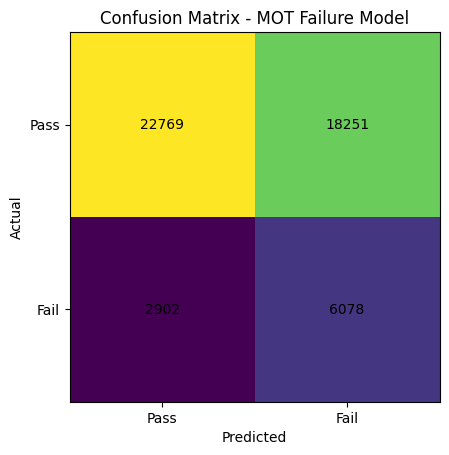

In [18]:
# Plot confusion matrix

plt.imshow(cm)
plt.title("Confusion Matrix - MOT Failure Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Pass", "Fail"])
plt.yticks([0, 1], ["Pass", "Fail"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [19]:
# Classification report

print(classification_report(y_test, y_pred, target_names=["Pass", "Fail"]))

              precision    recall  f1-score   support

        Pass       0.89      0.56      0.68     41020
        Fail       0.25      0.68      0.36      8980

    accuracy                           0.58     50000
   macro avg       0.57      0.62      0.52     50000
weighted avg       0.77      0.58      0.63     50000



## Save Model Outputs

The trained model and feature list will be saved into the models folder.

This allows the model to be reused later without retraining from scratch.

In [20]:
# Save model and feature list

model_file = models_path / "mot_failure_model.joblib"
feature_file = models_path / "model_feature_columns.joblib"

joblib.dump(model, model_file)
joblib.dump(
    {
        "numeric_features": numeric_features,
        "categorical_features": categorical_features
    },
    feature_file
)

print("Model saved:", model_file.exists())
print("Feature file saved:", feature_file.exists())

Model saved: True
Feature file saved: True


In [21]:
# Create model performance summary report

report_file = reports_path / "model_performance_summary.md"

report_text = f"""# MOT Failure Risk Model Performance Summary

## Model Type

Logistic Regression Classification Model

## Target Variable

The model predicts whether a vehicle is likely to fail its MOT.

- 1 = Fail
- 0 = Pass

## Features Used

### Numeric Features

{numeric_features}

### Categorical Features

{categorical_features}

## Model Performance

| Metric | Baseline | Logistic Regression |
|---|---:|---:|
| Accuracy | {baseline_accuracy:.3f} | {model_accuracy:.3f} |
| Precision | {baseline_precision:.3f} | {model_precision:.3f} |
| Recall | {baseline_recall:.3f} | {model_recall:.3f} |
| F1 Score | {baseline_f1:.3f} | {model_f1:.3f} |

## Business Interpretation

This model is designed to support MOT failure risk analysis and fleet maintenance planning.

The model should not replace expert vehicle inspection. Instead, it could be used to help prioritise vehicles for proactive maintenance review based on age, mileage, make, fuel type and vehicle class patterns.

## Limitations

- The model is based on a sample of 2024 MOT result data.
- The model does not include detailed defect item descriptions yet.
- The model does not include service history, repair history or driver behaviour.
- Predictions should be treated as risk indicators, not final maintenance decisions.
"""

report_file.write_text(report_text, encoding="utf-8")

print("Report created:", report_file.exists())

Report created: True


## Modelling Summary

This notebook created a basic MOT failure risk classification model.

The modelling process included:

- Preparing a pass/fail target variable
- Selecting numeric and categorical features
- Splitting the data into training and test sets
- Creating a simple baseline model
- Training a logistic regression model
- Evaluating accuracy, precision, recall and F1 score
- Saving the trained model and model performance report

The model is intended as a portfolio demonstration of predictive analytics and fleet maintenance risk thinking. It should be used to support maintenance judgement, not replace expert vehicle inspection.